In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
import time
import warnings
warnings.filterwarnings('ignore')

import sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, f1_score, brier_score_loss,
)
import xgboost as xgb

DATA_DIR  = Path('../data/processed')
FIG_DIR   = Path('../outputs/figures')
TABLE_DIR = Path('../outputs/tables')
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi'        : 150,
    'font.family'       : 'DejaVu Sans',
    'font.size'         : 11,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
})

print(f'sklearn : {sklearn.__version__}')
print(f'xgboost : {xgb.__version__}')
print('Imports good')

sklearn : 1.8.0
xgboost : 3.2.0
Imports good


In [55]:
df22 = pd.read_csv(DATA_DIR / 'brfss_2022_clean.csv')
df23 = pd.read_csv(DATA_DIR / 'brfss_2023_clean.csv')

print(f'2022 : {len(df22):,} rows × {df22.shape[1]} cols')
print(f'2023 : {len(df23):,} rows × {df23.shape[1]} cols')
print(f'2022 COPD prevalence (unweighted): {df22["COPD"].mean()*100:.2f}%')

2022 : 442,913 rows × 30 cols
2023 : 431,257 rows × 30 cols
2022 COPD prevalence (unweighted): 8.05%


In [56]:
#recode CHECKUP1 to 8 = no 5 = >5 years ago, 1-4 = more recent
for df in [df22, df23]:
    df['CHECKUP1'] = df['CHECKUP1'].replace({8.0: 5.0})

#Feature column sets
ORDINAL_FEATURES = [
    'INCOME3', 'EDUCA', 'SEXVAR', '_AGEG5YR', '_IMPRACE',
    'EMPLOY1', 'MARITAL', '_URBSTAT', '_SMOKER3', '_BMI5CAT',
    'PERSDOC3', 'CHECKUP1',
]
BINARY_FEATURES = [
    'EXERANY2', 'DRNKANY6', 'ASTHMA3', 'CVDINFR4', 'CVDCRHD4',
    'CVDSTRK3', 'HAVARTH3', 'CHCKDNY2', 'HLTHPLN2', 'MEDCOST1',
    'DIABETES', 'PREDIABETES',
]
ALL_FEATURES = ORDINAL_FEATURES + BINARY_FEATURES
OUTCOME      = 'COPD'
WEIGHT       = '_LLCPWT'

X_train_full = df22[ALL_FEATURES].copy()
y_train_full = df22[OUTCOME].copy()
X_test_full  = df23[ALL_FEATURES].copy()   
y_test_full  = df23[OUTCOME].copy()

print(f'Training features : {X_train_full.shape}')
print(f'Training outcome  : {y_train_full.shape}')
print(f'Positive class    : {y_train_full.sum():,} ({y_train_full.mean()*100:.1f}%)')
print(f'Feature columns   : {ALL_FEATURES}')

#check for columns missing
assert all(c in df22.columns for c in ALL_FEATURES), 'Missing feature columns in df22'
print('\nAll feature columns confirmed present.')

Training features : (442913, 24)
Training outcome  : (442913,)
Positive class    : 35,656 (8.1%)
Feature columns   : ['INCOME3', 'EDUCA', 'SEXVAR', '_AGEG5YR', '_IMPRACE', 'EMPLOY1', 'MARITAL', '_URBSTAT', '_SMOKER3', '_BMI5CAT', 'PERSDOC3', 'CHECKUP1', 'EXERANY2', 'DRNKANY6', 'ASTHMA3', 'CVDINFR4', 'CVDCRHD4', 'CVDSTRK3', 'HAVARTH3', 'CHCKDNY2', 'HLTHPLN2', 'MEDCOST1', 'DIABETES', 'PREDIABETES']

All feature columns confirmed present.


In [57]:
# Preprocessors — 24 features, no missingness indicators
# Tree-based models: impute only, no scaling
tree_preprocessor = ColumnTransformer(
    transformers=[
        ('ord', SimpleImputer(strategy='median'),        ORDINAL_FEATURES),
        ('bin', SimpleImputer(strategy='most_frequent'),  BINARY_FEATURES),
    ],
    remainder='drop'
)

# Logistic regression: impute + scale ordinal features
lr_preprocessor = ColumnTransformer(
    transformers=[
        ('ord', Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale',  StandardScaler()),
        ]), ORDINAL_FEATURES),
        ('bin', SimpleImputer(strategy='most_frequent'), BINARY_FEATURES),
    ],
    remainder='drop'
)

print('Preprocessors defined — 24 features, no missingness indicators.')
print(f'  Ordinal features ({len(ORDINAL_FEATURES)}): {ORDINAL_FEATURES}')
print(f'  Binary features  ({len(BINARY_FEATURES)}): {BINARY_FEATURES}')
print(f'  Total features: {len(ALL_FEATURES)}')

Preprocessors defined — 24 features, no missingness indicators.
  Ordinal features (12): ['INCOME3', 'EDUCA', 'SEXVAR', '_AGEG5YR', '_IMPRACE', 'EMPLOY1', 'MARITAL', '_URBSTAT', '_SMOKER3', '_BMI5CAT', 'PERSDOC3', 'CHECKUP1']
  Binary features  (12): ['EXERANY2', 'DRNKANY6', 'ASTHMA3', 'CVDINFR4', 'CVDCRHD4', 'CVDSTRK3', 'HAVARTH3', 'CHCKDNY2', 'HLTHPLN2', 'MEDCOST1', 'DIABETES', 'PREDIABETES']
  Total features: 24


In [58]:
#Class imbalance 
import pandas as pd
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import xgboost as xgb

if 'DATA_DIR' not in globals():
    DATA_DIR = Path('../data/processed')
if 'df22' not in globals():
    df22 = pd.read_csv(DATA_DIR / 'brfss_2022_clean.csv')
if 'df23' not in globals():
    df23 = pd.read_csv(DATA_DIR / 'brfss_2023_clean.csv')
if 'OUTCOME' not in globals():
    OUTCOME = 'COPD'
if 'ALL_FEATURES' not in globals():
    ORDINAL_FEATURES = [
        'INCOME3', 'EDUCA', 'SEXVAR', '_AGEG5YR', '_IMPRACE',
        'EMPLOY1', 'MARITAL', '_URBSTAT', '_SMOKER3', '_BMI5CAT',
        'PERSDOC3', 'CHECKUP1',
    ]
    BINARY_FEATURES = [
        'EXERANY2', 'DRNKANY6', 'ASTHMA3', 'CVDINFR4', 'CVDCRHD4',
        'CVDSTRK3', 'HAVARTH3', 'CHCKDNY2', 'HLTHPLN2', 'MEDCOST1',
        'DIABETES', 'PREDIABETES',
    ]
    ALL_FEATURES = ORDINAL_FEATURES + BINARY_FEATURES
if 'tree_preprocessor' not in globals():
    tree_preprocessor = ColumnTransformer(
        transformers=[
            ('ord', SimpleImputer(strategy='median'), ORDINAL_FEATURES),
            ('bin', SimpleImputer(strategy='most_frequent'), BINARY_FEATURES),
        ],
        remainder='drop',
    )
if 'lr_preprocessor' not in globals():
    lr_preprocessor = ColumnTransformer(
        transformers=[
            ('ord', Pipeline([
                ('impute', SimpleImputer(strategy='median')),
                ('scale', StandardScaler()),
            ]), ORDINAL_FEATURES),
            ('bin', SimpleImputer(strategy='most_frequent'), BINARY_FEATURES),
        ],
        remainder='drop',
    )

if 'y_train_full' not in globals():
    y_train_full = df22[OUTCOME].copy()
if 'X_train_full' not in globals():
    X_train_full = df22[ALL_FEATURES].copy()

n_neg = (y_train_full == 0).sum()
n_pos = y_train_full.sum()
scale_pos_weight = n_neg / n_pos
print(f'scale_pos_weight (XGBoost) = {scale_pos_weight:.2f}')

#define models
MODELS = {
    'Logistic Regression': Pipeline([
        ('pre', lr_preprocessor),
        ('clf', LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            solver='saga',
            random_state=42,
            n_jobs=-1,
        )),
    ]),

    'Decision Tree': Pipeline([
        ('pre', tree_preprocessor),
        ('clf', DecisionTreeClassifier(
            class_weight='balanced',
            max_depth=12,
            min_samples_leaf=50,
            random_state=42,
        )),
    ]),

    'Random Forest': Pipeline([
        ('pre', tree_preprocessor),
        ('clf', RandomForestClassifier(
            n_estimators=100,       # 100 for CV speed; bumped to 200 for final fit
            class_weight='balanced',
            max_features='sqrt',
            min_samples_leaf=50,
            random_state=42,
            n_jobs=-1,
        )),
    ]),

    'XGBoost': Pipeline([
        ('pre', tree_preprocessor),
        ('clf', xgb.XGBClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            tree_method='hist',     # fast for large datasets
            eval_metric='auc',
            random_state=42,
            n_jobs=-1,
            verbosity=0,
        )),
    ]),
}

print('Models defined:')
for name in MODELS:
    print(f'  {name}')

scale_pos_weight (XGBoost) = 11.42
Models defined:
  Logistic Regression
  Decision Tree
  Random Forest
  XGBoost


In [59]:
def youden_threshold(y_true, y_prob):
    """Return threshold that maximises Youden's J (sensitivity + specificity - 1)."""
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    j_scores = tpr - fpr
    return thresholds[np.argmax(j_scores)]

def evaluate_fold(y_true, y_prob, threshold=0.5):
    """Return dict of metrics for one fold at a given threshold."""
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'auc'         : roc_auc_score(y_true, y_prob),
        'ap'          : average_precision_score(y_true, y_prob),
        'sensitivity' : tp / (tp + fn) if (tp + fn) > 0 else 0,
        'specificity' : tn / (tn + fp) if (tn + fp) > 0 else 0,
        'f1'          : f1_score(y_true, y_pred, zero_division=0),
        'brier'       : brier_score_loss(y_true, y_prob),
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
    }

def run_cv(name, pipeline, X, y, n_splits=5):
    """Run stratified k-fold CV and return per-fold metrics + pooled ROC."""
    cv       = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_metrics = []
    all_y_true, all_y_prob = [], []

    t0 = time.time()
    for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        pipeline.fit(X_tr, y_tr)
        y_prob = pipeline.predict_proba(X_val)[:, 1]

        thresh = youden_threshold(y_val, y_prob)
        m = evaluate_fold(y_val, y_prob, threshold=thresh)
        m['fold']              = fold + 1
        m['youden_threshold']  = thresh
        # Also record 0.5-threshold metrics
        m05 = evaluate_fold(y_val, y_prob, threshold=0.5)
        m['sensitivity_05'] = m05['sensitivity']
        m['specificity_05'] = m05['specificity']
        m['f1_05']          = m05['f1']

        fold_metrics.append(m)
        all_y_true.extend(y_val.tolist())
        all_y_prob.extend(y_prob.tolist())

        print(f'    Fold {fold+1}: AUC={m["auc"]:.4f}  '
              f'Sens={m["sensitivity"]:.3f}  Spec={m["specificity"]:.3f}  '
              f'(Youden threshold={thresh:.3f})')

    elapsed = time.time() - t0
    print(f'  → {elapsed:.1f}s')

    fold_df = pd.DataFrame(fold_metrics)
    return fold_df, np.array(all_y_true), np.array(all_y_prob)

In [60]:
#CV results storage and curves 

CV_RESULTS = {}   # name → fold_df
CV_CURVES  = {}   # name → (y_true, y_prob) pooled across folds

print('=== 5-Fold Stratified CV — BRFSS 2022 ===\n')

for name, pipeline in MODELS.items():
    print(f'[{name}]')
    fold_df, y_true_pool, y_prob_pool = run_cv(
        name, pipeline, X_train_full, y_train_full
    )
    CV_RESULTS[name] = fold_df
    CV_CURVES[name]  = (y_true_pool, y_prob_pool)
    print()

print('CV complete.')

=== 5-Fold Stratified CV — BRFSS 2022 ===

[Logistic Regression]


    Fold 1: AUC=0.8455  Sens=0.773  Spec=0.763  (Youden threshold=0.493)
    Fold 2: AUC=0.8461  Sens=0.800  Spec=0.739  (Youden threshold=0.463)
    Fold 3: AUC=0.8475  Sens=0.791  Spec=0.750  (Youden threshold=0.477)
    Fold 4: AUC=0.8498  Sens=0.781  Spec=0.762  (Youden threshold=0.487)
    Fold 5: AUC=0.8471  Sens=0.782  Spec=0.758  (Youden threshold=0.486)
  → 28.2s

[Decision Tree]
    Fold 1: AUC=0.8360  Sens=0.755  Spec=0.774  (Youden threshold=0.505)
    Fold 2: AUC=0.8361  Sens=0.760  Spec=0.776  (Youden threshold=0.519)
    Fold 3: AUC=0.8388  Sens=0.785  Spec=0.750  (Youden threshold=0.488)
    Fold 4: AUC=0.8405  Sens=0.776  Spec=0.762  (Youden threshold=0.492)
    Fold 5: AUC=0.8361  Sens=0.736  Spec=0.793  (Youden threshold=0.554)
  → 9.6s

[Random Forest]
    Fold 1: AUC=0.8544  Sens=0.799  Spec=0.754  (Youden threshold=0.473)
    Fold 2: AUC=0.8547  Sens=0.768  Spec=0.789  (Youden threshold=0.512)
    Fold 3: AUC=0.8558  Sens=0.817  Spec=0.741  (Youden threshold=0.455

In [61]:
# summarize results in a table with mean±std across folds for each metric, and also save per-fold results to CSV for later analysis/plotting

summary_rows = []
for name, fold_df in CV_RESULTS.items():
    row = {'Model': name}
    for metric in ['auc', 'sensitivity', 'specificity', 'f1',
                   'sensitivity_05', 'specificity_05', 'f1_05',
                   'ap', 'brier', 'youden_threshold']:
        row[f'{metric}_mean'] = fold_df[metric].mean()
        row[f'{metric}_std']  = fold_df[metric].std()
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)

print('=== CV Results (Youden-optimal threshold unless noted) ===\n')
print(f'{"Model":<22} {"AUC":>10} {"Sensitivity":>13} {"Specificity":>13} '
      f'{"F1":>8} {"Brier":>8} {"Threshold":>11}')
print('-' * 90)

for _, r in summary_df.iterrows():
    print(f'{r["Model"]:<22} '
          f'{r["auc_mean"]:.4f}±{r["auc_std"]:.4f}  '
          f'{r["sensitivity_mean"]:.3f}±{r["sensitivity_std"]:.3f}  '
          f'{r["specificity_mean"]:.3f}±{r["specificity_std"]:.3f}  '
          f'{r["f1_mean"]:.3f}±{r["f1_std"]:.3f}  '
          f'{r["brier_mean"]:.4f}±{r["brier_std"]:.4f}  '
          f'{r["youden_threshold_mean"]:.3f}±{r["youden_threshold_std"]:.3f}')

print()
print('At 0.5 threshold:')
print(f'{"Model":<22} {"Sensitivity@0.5":>16} {"Specificity@0.5":>16} {"F1@0.5":>10}')
print('-' * 70)
for _, r in summary_df.iterrows():
    print(f'{r["Model"]:<22} '
          f'{r["sensitivity_05_mean"]:.3f}±{r["sensitivity_05_std"]:.3f}         '
          f'{r["specificity_05_mean"]:.3f}±{r["specificity_05_std"]:.3f}         '
          f'{r["f1_05_mean"]:.3f}±{r["f1_05_std"]:.3f}')

summary_df.to_csv(TABLE_DIR / 'baseline_cv_summary.csv', index=False)
for name, fold_df in CV_RESULTS.items():
    fname = name.lower().replace(' ', '_')
    fold_df.to_csv(TABLE_DIR / f'baseline_cv_folds_{fname}.csv', index=False)
print('\nSaved baseline_cv_summary.csv and per-model fold CSVs.')   

=== CV Results (Youden-optimal threshold unless noted) ===

Model                         AUC   Sensitivity   Specificity       F1    Brier   Threshold
------------------------------------------------------------------------------------------
Logistic Regression    0.8472±0.0016  0.785±0.010  0.754±0.010  0.342±0.005  0.1589±0.0006  0.481±0.012
Decision Tree          0.8375±0.0020  0.762±0.019  0.771±0.016  0.349±0.007  0.1574±0.0008  0.511±0.027
Random Forest          0.8558±0.0022  0.795±0.018  0.765±0.018  0.355±0.011  0.1476±0.0008  0.483±0.021
XGBoost                0.8575±0.0020  0.793±0.011  0.769±0.009  0.358±0.005  0.1476±0.0009  0.476±0.013

At 0.5 threshold:
Model                   Sensitivity@0.5  Specificity@0.5     F1@0.5
----------------------------------------------------------------------
Logistic Regression    0.767±0.002         0.771±0.002         0.350±0.002
Decision Tree          0.766±0.006         0.766±0.003         0.345±0.002
Random Forest          0.779±0.00

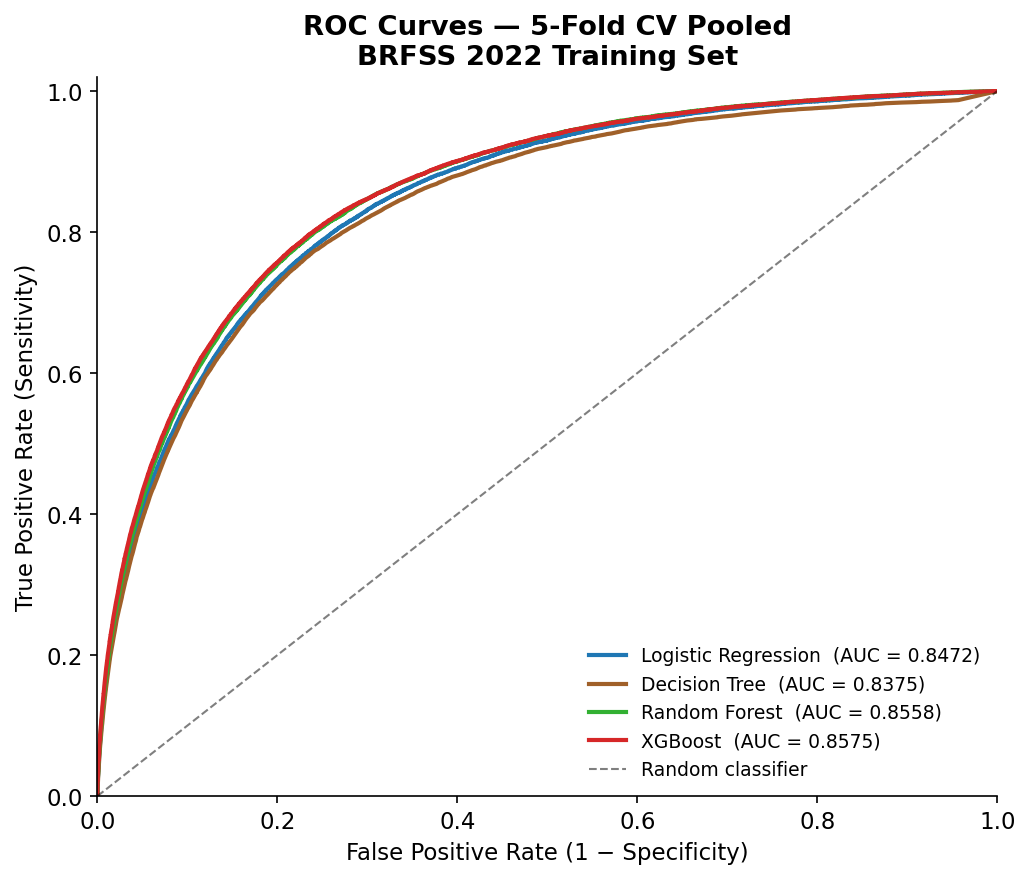

Saved fig06_roc_curves.png


In [62]:
MODEL_COLORS = {
    'Logistic Regression' : '#1F77B4',
    'Decision Tree'       : "#A06029",
    'Random Forest'       : "#32B032",
    'XGBoost'             : '#D62728',
}

fig, ax = plt.subplots(figsize=(7, 6))

for name, (y_true, y_prob) in CV_CURVES.items():
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    ax.plot(fpr, tpr, lw=2, color=MODEL_COLORS[name],
            label=f'{name}  (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random classifier')
ax.set_xlabel('False Positive Rate (1 − Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.set_title('ROC Curves — 5-Fold CV Pooled\nBRFSS 2022 Training Set', fontweight='bold')
ax.legend(frameon=False, fontsize=9, loc='lower right')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig06_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig06_roc_curves.png')

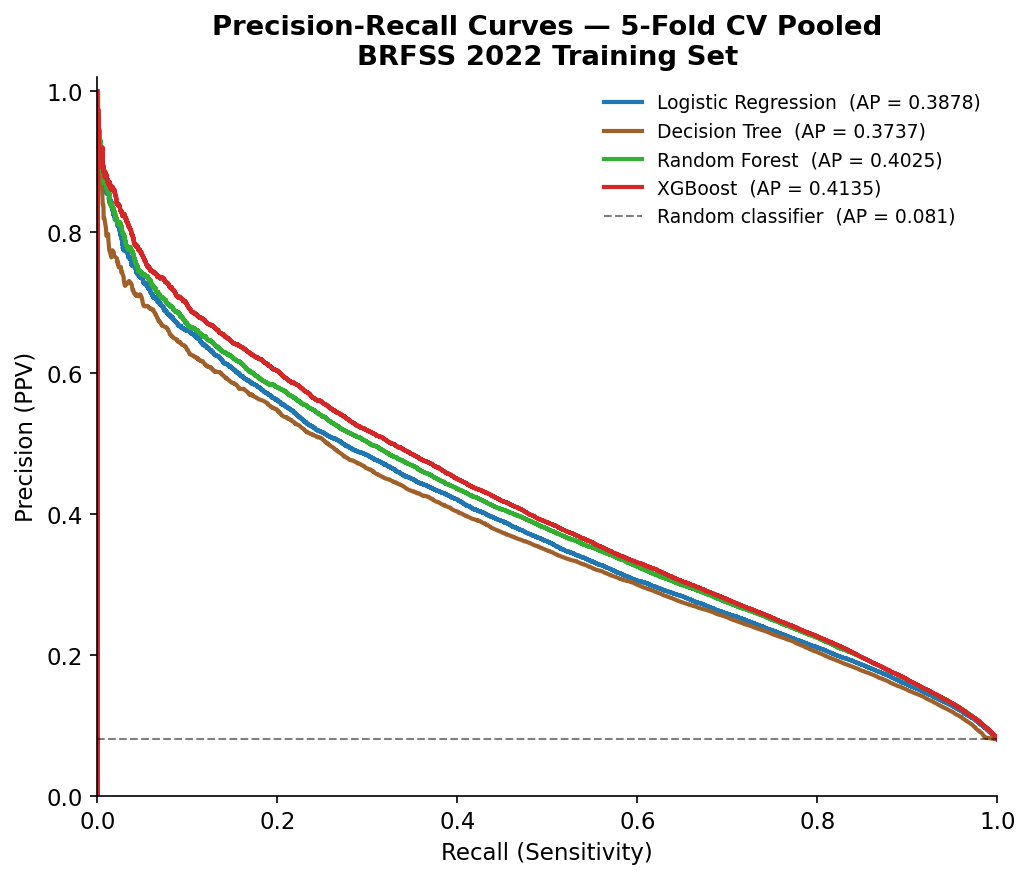

Saved fig07_pr_curves.png


In [63]:
#PR Curves

fig, ax = plt.subplots(figsize=(7, 6))
baseline_precision = y_train_full.mean()

for name, (y_true, y_prob) in CV_CURVES.items():
    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)
    ax.plot(rec, prec, lw=2, color=MODEL_COLORS[name],
            label=f'{name}  (AP = {ap:.4f})')

ax.axhline(baseline_precision, color='k', ls='--', lw=1, alpha=0.5,
           label=f'Random classifier  (AP = {baseline_precision:.3f})')
ax.set_xlabel('Recall (Sensitivity)')
ax.set_ylabel('Precision (PPV)')
ax.set_title('Precision-Recall Curves — 5-Fold CV Pooled\nBRFSS 2022 Training Set',
             fontweight='bold')
ax.legend(frameon=False, fontsize=9, loc='upper right')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig07_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig07_pr_curves.png')

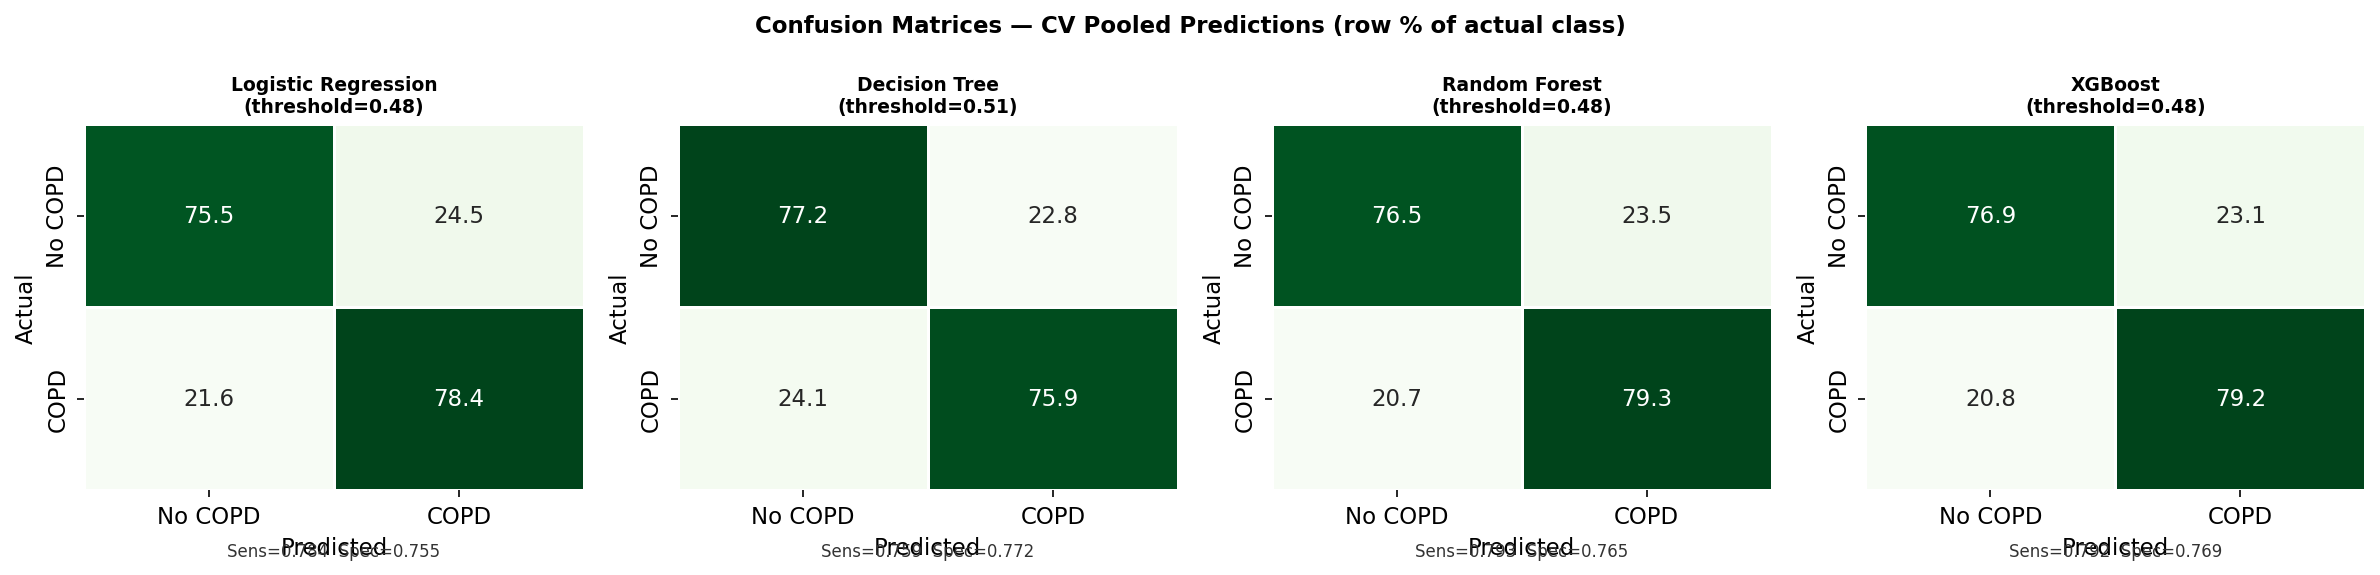

Saved fig08_confusion_matrices.png


In [64]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (name, (y_true, y_prob)) in zip(axes, CV_CURVES.items()):
    thresh = summary_df.loc[summary_df['Model'] == name,
                            'youden_threshold_mean'].values[0]
    y_pred = (y_prob >= thresh).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Greens', ax=ax,
                xticklabels=['No COPD', 'COPD'],
                yticklabels=['No COPD', 'COPD'],
                cbar=False, linewidths=0.5)
    ax.set_title(f'{name}\n(threshold={thresh:.2f})', fontsize=9, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

    tn, fp, fn, tp = cm.ravel()
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)
    ax.text(0.5, -0.18, f'Sens={sens:.3f}  Spec={spec:.3f}',
            transform=ax.transAxes, ha='center', fontsize=8, color='#333')

plt.suptitle('Confusion Matrices — CV Pooled Predictions (row % of actual class)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig08_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig08_confusion_matrices.png')

In [65]:
#refit on full training data and save models for test set evaluation (2022)

print('Fitting final models on full BRFSS 2022...\n')

FINAL_MODELS = {
    'Logistic Regression': Pipeline([
        ('pre', lr_preprocessor),
        ('clf', LogisticRegression(
            class_weight='balanced', max_iter=1000,
            solver='saga', random_state=42, n_jobs=-1,
        )),
    ]),
    'Decision Tree': Pipeline([
        ('pre', tree_preprocessor),
        ('clf', DecisionTreeClassifier(
            class_weight='balanced', max_depth=12,
            min_samples_leaf=50, random_state=42,
        )),
    ]),
    'Random Forest': Pipeline([
        ('pre', tree_preprocessor),
        ('clf', RandomForestClassifier(
            n_estimators=200, class_weight='balanced',
            max_features='sqrt', min_samples_leaf=50,
            random_state=42, n_jobs=-1,
        )),
    ]),
    'XGBoost': Pipeline([
        ('pre', tree_preprocessor),
        ('clf', xgb.XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            tree_method='hist', eval_metric='auc',
            random_state=42, n_jobs=-1, verbosity=0,
        )),
    ]),
}

for name, pipeline in FINAL_MODELS.items():
    t0 = time.time()
    pipeline.fit(X_train_full, y_train_full)
    print(f'  {name}: {time.time()-t0:.1f}s')

print('\nFinal models fitted.')

Fitting final models on full BRFSS 2022...

  Logistic Regression: 7.1s
  Decision Tree: 2.0s
  Random Forest: 19.2s
  XGBoost: 3.5s

Final models fitted.


In [66]:
FEATURE_NAMES_OUT = ALL_FEATURES 

importance_dfs = {}

for name, pipeline in FINAL_MODELS.items():
    clf = pipeline.named_steps['clf']

    if name == 'Logistic Regression':
        # Coefficients (log-odds): sign matters, use abs for ranking
        importances = np.abs(clf.coef_[0])
    elif name == 'Decision Tree':
        importances = clf.feature_importances_
    elif name == 'Random Forest':
        importances = clf.feature_importances_
    elif name == 'XGBoost':
        importances = clf.feature_importances_

    imp_df = pd.DataFrame({
        'feature'    : FEATURE_NAMES_OUT,
        'importance' : importances,
        'model'      : name,
    }).sort_values('importance', ascending=False)

    importance_dfs[name] = imp_df

    fname = name.lower().replace(' ', '_')
    imp_df.to_csv(TABLE_DIR / f'feature_importance_{fname}.csv', index=False)
    print(f'{name} — top 5:')
    print(imp_df.head(5)[['feature', 'importance']].to_string(index=False))
    print()

print('Feature importance CSVs saved.')

Logistic Regression — top 5:
 feature  importance
 ASTHMA3    1.571018
CVDCRHD4    0.582769
_SMOKER3    0.573401
HAVARTH3    0.553151
MEDCOST1    0.547265

Decision Tree — top 5:
 feature  importance
_SMOKER3    0.332164
 ASTHMA3    0.208773
 EMPLOY1    0.125303
_AGEG5YR    0.086244
HAVARTH3    0.072430

Random Forest — top 5:
 feature  importance
_SMOKER3    0.210177
 ASTHMA3    0.150572
 EMPLOY1    0.131611
HAVARTH3    0.112084
_AGEG5YR    0.096042

XGBoost — top 5:
 feature  importance
 ASTHMA3    0.276083
_SMOKER3    0.202162
HAVARTH3    0.133789
 EMPLOY1    0.068659
CVDCRHD4    0.042682

Feature importance CSVs saved.


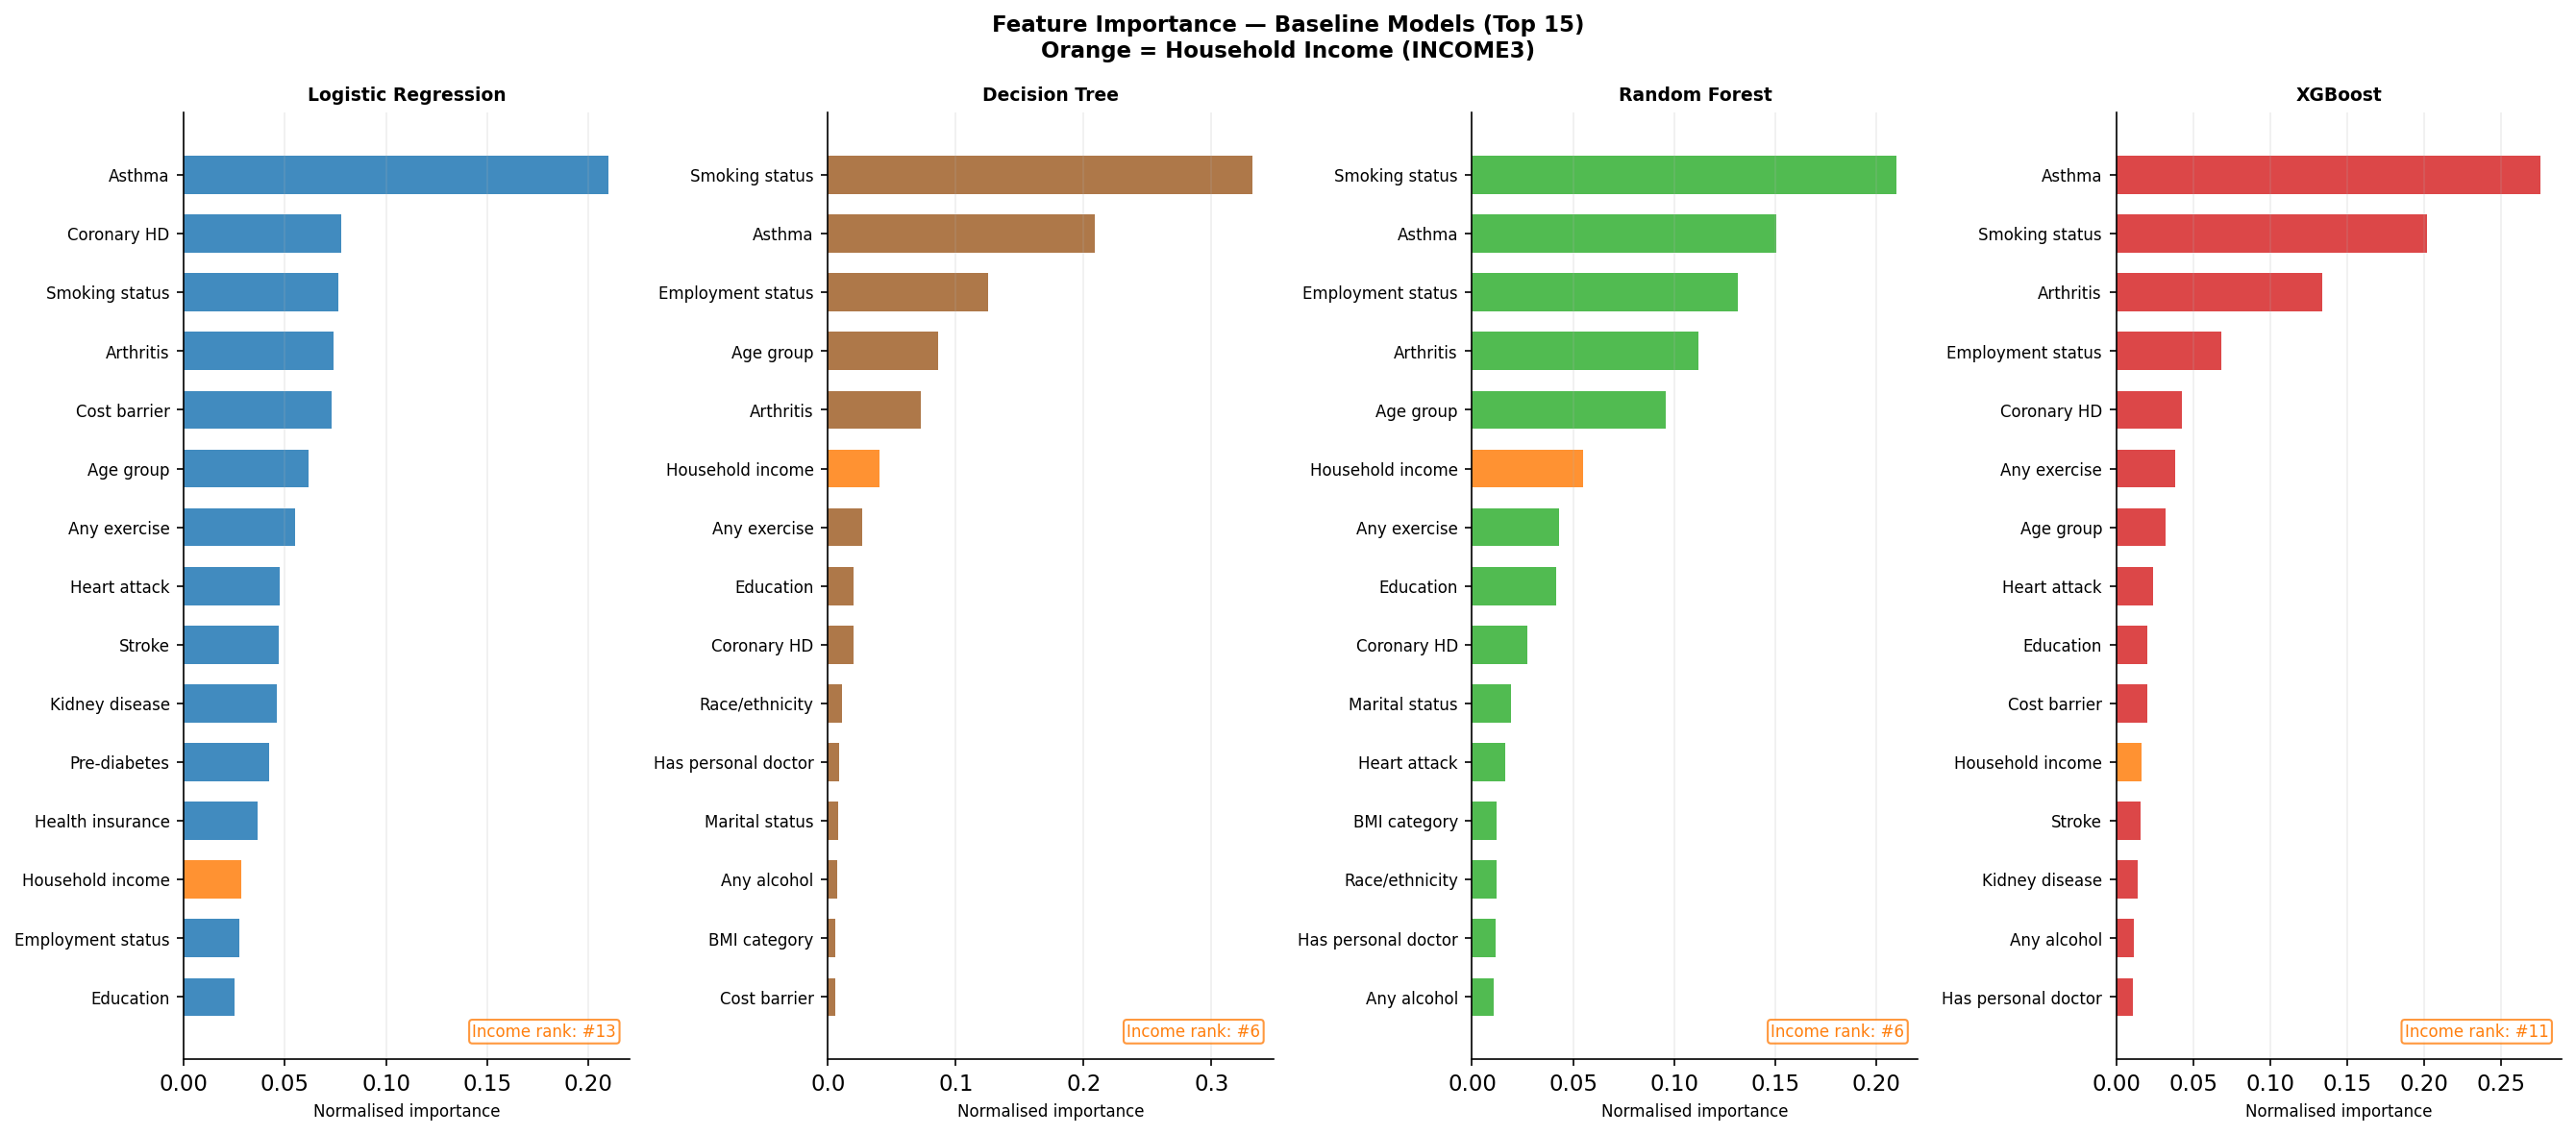

Saved fig09_feature_importance.png


In [67]:
VAR_LABELS = {
    'INCOME3'    : 'Household income',
    'EDUCA'      : 'Education',
    'SEXVAR'     : 'Sex',
    '_AGEG5YR'   : 'Age group',
    '_IMPRACE'   : 'Race/ethnicity',
    'EMPLOY1'    : 'Employment status',
    'MARITAL'    : 'Marital status',
    '_URBSTAT'   : 'Urban/Rural',
    '_SMOKER3'   : 'Smoking status',
    '_BMI5CAT'   : 'BMI category',
    'PERSDOC3'   : 'Has personal doctor',
    'CHECKUP1'   : 'Last checkup',
    'EXERANY2'   : 'Any exercise',
    'DRNKANY6'   : 'Any alcohol',
    'ASTHMA3'    : 'Asthma',
    'CVDINFR4'   : 'Heart attack',
    'CVDCRHD4'   : 'Coronary HD',
    'CVDSTRK3'   : 'Stroke',
    'HAVARTH3'   : 'Arthritis',
    'CHCKDNY2'   : 'Kidney disease',
    'HLTHPLN2'   : 'Health insurance',
    'MEDCOST1'   : 'Cost barrier',
    'DIABETES'   : 'Diabetes',
    'PREDIABETES': 'Pre-diabetes',
}

fig, axes = plt.subplots(1, 4, figsize=(18, 8), sharey=False)

for ax, (name, imp_df) in zip(axes, importance_dfs.items()):
    # Normalise to 0–1 for comparability across models
    imp_norm = imp_df.copy()
    imp_norm['importance'] = (imp_norm['importance'] /
                               imp_norm['importance'].sum())
    top15 = imp_norm.head(15).copy()
    top15['label'] = top15['feature'].map(VAR_LABELS)

    # Highlight INCOME3
    colors = [MODEL_COLORS[name] if f != 'INCOME3' else '#FF7F0E'
              for f in top15['feature']]

    ax.barh(range(len(top15)), top15['importance'],
            color=colors, alpha=0.85, height=0.65)
    ax.set_yticks(range(len(top15)))
    ax.set_yticklabels(top15['label'], fontsize=8)
    ax.set_title(name, fontsize=9, fontweight='bold')
    ax.set_xlabel('Normalised importance', fontsize=8)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.2)

    # Annotate income rank
    income_rank = list(imp_norm['feature']).index('INCOME3') + 1
    ax.text(0.97, 0.02, f'Income rank: #{income_rank}',
            transform=ax.transAxes, ha='right', va='bottom',
            fontsize=8, color='#FF7F0E',
            bbox=dict(boxstyle='round,pad=0.2', fc='white',
                      ec='#FF7F0E', alpha=0.8))

plt.suptitle('Feature Importance — Baseline Models (Top 15)\n'
             'Orange = Household Income (INCOME3)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig09_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig09_feature_importance.png')


In [68]:
#compare class weight vs SMOTE for Random Forest (3-fold for speed)

try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    SMOTE_AVAILABLE = True
except ImportError:
    SMOTE_AVAILABLE = False
    print('imbalanced-learn not installed. Skipping SMOTE check.')
    print('Install with: pip install imbalanced-learn')

if SMOTE_AVAILABLE:
    print('Running SMOTE sensitivity check on Random Forest (3-fold for speed)...\n')

    cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    # Pipeline A: class_weight
    # Pipeline B: SMOTE
    results_comparison = {'class_weight': [], 'SMOTE': []}

    pipe_cw = Pipeline([
        ('pre', tree_preprocessor),
        ('clf', RandomForestClassifier(
            n_estimators=100, class_weight='balanced',
            max_features='sqrt', min_samples_leaf=50,
            random_state=42, n_jobs=-1,
        )),
    ])

    pipe_smote = ImbPipeline([
        ('pre',  tree_preprocessor),
        ('smote', SMOTE(sampling_strategy=0.25, random_state=42),
        ('clf',  RandomForestClassifier(
            n_estimators=100, max_features='sqrt',
            min_samples_leaf=50, random_state=42, n_jobs=-1)
        )),
    ])

    for fold, (tr_idx, val_idx) in enumerate(cv3.split(X_train_full, y_train_full)):
        X_tr = X_train_full.iloc[tr_idx]
        X_val = X_train_full.iloc[val_idx]
        y_tr = y_train_full.iloc[tr_idx]
        y_val = y_train_full.iloc[val_idx]

        for label, pipe in [('class_weight', pipe_cw), ('SMOTE', pipe_smote)]:
            if label == 'SMOTE':
                # Rebuild SMOTE pipeline defensively (fix malformed step tuple)
                pipe = ImbPipeline([
                    ('pre', tree_preprocessor),
                    ('smote', SMOTE(sampling_strategy=0.25, random_state=42)),
                    ('clf', RandomForestClassifier(
                        n_estimators=100, max_features='sqrt',
                        min_samples_leaf=50, random_state=42, n_jobs=-1,
                    )),
                ])
            pipe.fit(X_tr, y_tr)
            y_prob = pipe.predict_proba(X_val)[:, 1]
            thresh = youden_threshold(y_val, y_prob)
            m = evaluate_fold(y_val, y_prob, threshold=thresh)
            results_comparison[label].append(m)

    print(f'{"Strategy":<16} {"AUC":>8} {"Sensitivity":>13} {"Specificity":>13}')
    print('-' * 55)
    for label, folds in results_comparison.items():
        auc  = np.mean([f['auc'] for f in folds])
        sens = np.mean([f['sensitivity'] for f in folds])
        spec = np.mean([f['specificity'] for f in folds])
        print(f'{label:<16} {auc:>8.4f} {sens:>13.3f} {spec:>13.3f}')

    print()
    print('Decision rule:')
    print('  SMOTE gains > 3% sensitivity AND loses < 2% AUC → adopt SMOTE')
    print('  Otherwise → class_weight="balanced" is sufficient')

Running SMOTE sensitivity check on Random Forest (3-fold for speed)...

Strategy              AUC   Sensitivity   Specificity
-------------------------------------------------------
class_weight       0.8556         0.790         0.770
SMOTE              0.8553         0.793         0.766

Decision rule:
  SMOTE gains > 3% sensitivity AND loses < 2% AUC → adopt SMOTE
  Otherwise → class_weight="balanced" is sufficient


In [69]:

def youden_threshold(y_true, y_prob):
      fpr, tpr, thresholds = roc_curve(y_true, y_prob)
      return float(thresholds[np.argmax(tpr - fpr)])

def evaluate_fold(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'auc': roc_auc_score(y_true, y_prob),
        'sensitivity': tp / (tp + fn) if (tp + fn) > 0 else 0,
        'specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'brier': brier_score_loss(y_true, y_prob),
        'ap': average_precision_score(y_true, y_prob),
    }

import numpy as np
from sklearn.metrics import (
    roc_curve, roc_auc_score, confusion_matrix,
    f1_score, brier_score_loss, average_precision_score)

try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    from sklearn.model_selection import StratifiedKFold
    SMOTE_AVAILABLE = True
except ImportError:
    SMOTE_AVAILABLE = False
    print('imbalanced-learn not installed. Skipping SMOTE check.')
    print('Install with: pip install imbalanced-learn')

if SMOTE_AVAILABLE:
    print("Running SMOTE sensitivity check on Random Forest (3-fold for speed)...\n")

    cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    results_comparison = {"class_weight": [], "SMOTE": []}

    for fold, (tr_idx, val_idx) in enumerate(cv3.split(X_train_full, y_train_full)):
        X_tr = X_train_full.iloc[tr_idx]
        X_val = X_train_full.iloc[val_idx]
        y_tr = y_train_full.iloc[tr_idx]
        y_val = y_train_full.iloc[val_idx]

        # Pipeline A: class_weight='balanced'
        pipe_cw = Pipeline([
            ("pre", tree_preprocessor),
            ("clf", RandomForestClassifier(
                n_estimators=100,
                class_weight="balanced",
                max_features="sqrt",
                min_samples_leaf=50,
                random_state=42,
                n_jobs=-1,
            )),
        ])
        pipe_cw.fit(X_tr, y_tr)
        y_prob_cw = pipe_cw.predict_proba(X_val)[:, 1]
        thresh_cw = youden_threshold(y_val, y_prob_cw)
        m_cw = evaluate_fold(y_val, y_prob_cw, threshold=thresh_cw)
        results_comparison["class_weight"].append(m_cw)

        # Pipeline B: SMOTE
        pipe_smote = ImbPipeline([
            ("pre", tree_preprocessor),
            ("smote", SMOTE(sampling_strategy=0.25, random_state=42)),
            ("clf", RandomForestClassifier(
                n_estimators=100,
                max_features="sqrt",
                min_samples_leaf=50,
                random_state=42,
                n_jobs=-1,
            )),
        ])
        pipe_smote.fit(X_tr, y_tr)
        y_prob_sm = pipe_smote.predict_proba(X_val)[:, 1]
        thresh_sm = youden_threshold(y_val, y_prob_sm)
        m_sm = evaluate_fold(y_val, y_prob_sm, threshold=thresh_sm)
        results_comparison["SMOTE"].append(m_sm)

        print(
            f'  Fold {fold + 1}: '
            f'class_weight AUC={m_cw["auc"]:.4f} Sens={m_cw["sensitivity"]:.3f}  |  '
            f'SMOTE AUC={m_sm["auc"]:.4f} Sens={m_sm["sensitivity"]:.3f}'
        )

    print()
    for label in ["class_weight", "SMOTE"]:
        aucs = [m["auc"] for m in results_comparison[label]]
        senss = [m["sensitivity"] for m in results_comparison[label]]
        specs = [m["specificity"] for m in results_comparison[label]]
        print(
            f"{label:<15} AUC={np.mean(aucs):.4f}±{np.std(aucs):.4f}  "
            f"Sens={np.mean(senss):.3f}  Spec={np.mean(specs):.3f}"
        )

    auc_cw = np.mean([m["auc"] for m in results_comparison["class_weight"]])
    auc_sm = np.mean([m["auc"] for m in results_comparison["SMOTE"]])
    sens_cw = np.mean([m["sensitivity"] for m in results_comparison["class_weight"]])
    sens_sm = np.mean([m["sensitivity"] for m in results_comparison["SMOTE"]])

    print(f"\nΔAUC (SMOTE − class_weight): {auc_sm - auc_cw:+.4f}")
    print(f"ΔSens (SMOTE − class_weight): {sens_sm - sens_cw:+.3f}")

    if abs(auc_sm - auc_cw) < 0.02 and abs(sens_sm - sens_cw) < 0.03:
        print('\n SMOTE does not meaningfully improve over class_weight.')
        print('  Proceeding with class_weight="balanced" for simplicity.')
    elif auc_sm > auc_cw and sens_sm > sens_cw:
        print("\n SMOTE improves both AUC and sensitivity.")
        print("  Consider SMOTE pipeline for final models.")
    else:
        print('\n~ Mixed results. class_weight="balanced" is simpler and sufficient.')

Running SMOTE sensitivity check on Random Forest (3-fold for speed)...

  Fold 1: class_weight AUC=0.8550 Sens=0.788  |  SMOTE AUC=0.8552 Sens=0.795
  Fold 2: class_weight AUC=0.8540 Sens=0.791  |  SMOTE AUC=0.8533 Sens=0.786
  Fold 3: class_weight AUC=0.8578 Sens=0.789  |  SMOTE AUC=0.8574 Sens=0.798

class_weight    AUC=0.8556±0.0016  Sens=0.790  Spec=0.770
SMOTE           AUC=0.8553±0.0016  Sens=0.793  Spec=0.766

ΔAUC (SMOTE − class_weight): -0.0003
ΔSens (SMOTE − class_weight): +0.003

 SMOTE does not meaningfully improve over class_weight.
  Proceeding with class_weight="balanced" for simplicity.


In [ ]:
import joblib

MODEL_DIR = Path('../outputs/models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Refit each model on full 2022 training data and serialize
# RF uses n_estimators=200 for final fit (vs 100 in CV)
FINAL_MODELS = {
    'Logistic Regression': Pipeline([
        ('pre', lr_preprocessor),
        ('clf', LogisticRegression(
            class_weight='balanced', max_iter=1000,
            solver='saga', random_state=42, n_jobs=-1,
        )),
    ]),
    'Decision Tree': Pipeline([
        ('pre', tree_preprocessor),
        ('clf', DecisionTreeClassifier(
            class_weight='balanced', max_depth=12,
            min_samples_leaf=50, random_state=42,
        )),
    ]),
    'Random Forest': Pipeline([
        ('pre', tree_preprocessor),
        ('clf', RandomForestClassifier(
            n_estimators=200, class_weight='balanced',
            max_features='sqrt', min_samples_leaf=50,
            random_state=42, n_jobs=-1,
        )),
    ]),
    'XGBoost': Pipeline([
        ('pre', tree_preprocessor),
        ('clf', xgb.XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=11.4, tree_method='hist',
            random_state=42, n_jobs=-1, eval_metric='logloss',
        )),
    ]),
}

print('Fitting final models on full 2022 training data...')
for name, pipe in FINAL_MODELS.items():
    pipe.fit(X_train_full, y_train_full)
    path = MODEL_DIR / f'{name.lower().replace(" ", "_")}_final.pkl'
    joblib.dump(pipe, path)
    print(f'  Saved: {path.name}')

print('\nAll final models serialized to outputs/models/')
print('Load in nb06 and nb07 with: joblib.load(MODEL_DIR / "model_name_final.pkl")')

Fitting final models on full 2022 training data...
  Saved: logistic_regression_final.pkl
  Saved: decision_tree_final.pkl
  Saved: random_forest_final.pkl
  Saved: xgboost_final.pkl

All final models serialized to outputs/models/
Load in nb06 and nb07 with: joblib.load(MODEL_DIR / "model_name_final.pkl")


In [71]:
# H1 decision point: is baseline performance strong enough to proceed with interaction analysis in notebooks 04-09?
print('=== DECISION POINT ===\n')

best_model = summary_df.loc[summary_df['auc_mean'].idxmax(), 'Model']
best_auc   = summary_df['auc_mean'].max()
best_sens  = summary_df.loc[summary_df['auc_mean'].idxmax(), 'sensitivity_mean']
best_spec  = summary_df.loc[summary_df['auc_mean'].idxmax(), 'specificity_mean']

print(f'Best model     : {best_model}')
print(f'Best CV AUC    : {best_auc:.4f}')
print(f'Sensitivity    : {best_sens:.3f}  (at Youden-optimal threshold)')
print(f'Specificity    : {best_spec:.3f}  (at Youden-optimal threshold)')
print()

if best_auc >= 0.80:
    print('✓ AUC ≥ 0.80 — H1 threshold met. Strong baseline.')
    print('  Proceed to notebooks 04 → 09.')
elif best_auc >= 0.72:
    print('✓ AUC ≥ 0.72 — Acceptable baseline.')
    print('  Proceed to notebooks 04 → 09.')
    print('  Frame as establishing the first BRFSS COPD individual-level baseline.')
else:
    print('⚠ AUC < 0.72 — Below pre-specified threshold.')
    print('  Pause before investing in interaction analysis.')
    print('  Review: feature engineering, imputation strategy,')
    print('  hyperparameter tuning, or reframe paper scope.')

print()

# Income rank summary across models
print('=== INCOME RANK ACROSS MODELS (H2 pre-check) ===\n')
for name, imp_df in importance_dfs.items():
    rank = list(imp_df['feature']).index('INCOME3') + 1
    print(f'  {name:<22} Income rank: #{rank} of {len(imp_df)}')

print()
print('H2 prediction: income ranks lower in LR than in RF/XGBoost.')
print('If LR rank > RF/XGBoost rank, that is additive vs non-additive signal.')

# Save final results table 
print()
final_results = summary_df[['Model', 'auc_mean', 'auc_std',
                              'sensitivity_mean', 'sensitivity_std',
                              'specificity_mean', 'specificity_std',
                              'f1_mean', 'f1_std',
                              'ap_mean', 'ap_std',
                              'brier_mean', 'brier_std',
                              'youden_threshold_mean']].copy()
final_results.columns = [
    'Model', 'AUC', 'AUC_std',
    'Sensitivity', 'Sensitivity_std',
    'Specificity', 'Specificity_std',
    'F1', 'F1_std',
    'AP', 'AP_std',
    'Brier', 'Brier_std',
    'Youden_threshold',
]
final_results.to_csv(TABLE_DIR / 'baseline_results.csv', index=False)

print('Saved:')
print('  baseline_results.csv')
print('  baseline_cv_summary.csv')
print('  baseline_cv_folds_[model].csv  (×4)')
print('  feature_importance_[model].csv  (×4)')

=== DECISION POINT ===

Best model     : XGBoost
Best CV AUC    : 0.8575
Sensitivity    : 0.793  (at Youden-optimal threshold)
Specificity    : 0.769  (at Youden-optimal threshold)

✓ AUC ≥ 0.80 — H1 threshold met. Strong baseline.
  Proceed to notebooks 04 → 09.

=== INCOME RANK ACROSS MODELS (H2 pre-check) ===

  Logistic Regression    Income rank: #13 of 24
  Decision Tree          Income rank: #6 of 24
  Random Forest          Income rank: #6 of 24
  XGBoost                Income rank: #11 of 24

H2 prediction: income ranks lower in LR than in RF/XGBoost.
If LR rank > RF/XGBoost rank, that is additive vs non-additive signal.

Saved:
  baseline_results.csv
  baseline_cv_summary.csv
  baseline_cv_folds_[model].csv  (×4)
  feature_importance_[model].csv  (×4)
